<a href="https://colab.research.google.com/github/patkaryash/CSL701-CE36_Machine-Learning-Lab/blob/main/Experiment/MLExp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Yash Anand Patkar RollNo:CE36 Batch:CE3

Step 1 — Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Step 2 — Upload and Load Dataset

In [7]:
from google.colab import files
import io

uploaded = files.upload()
# Get the filename dynamically from the uploaded dictionary keys
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"Successfully loaded: {filename}")
df.head()

Saving auto-mpg (2).csv to auto-mpg (2) (2).csv
Successfully loaded: auto-mpg (2) (2).csv


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


Step 3: Display the Dataset

In [14]:
print(df.head())

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model year  origin                   car name  
0          70       1  chevrolet chevelle malibu  
1          70       1          buick skylark 320  
2          70       1         plymouth satellite  
3          70       1              amc rebel sst  
4          70       1                ford torino  


Step 4: Data Preprocessing

In [15]:
print(df.isnull().sum())

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64


Replace missing values (?)

In [16]:
df["horsepower"] = df["horsepower"].replace('?', np.nan)

Convert horsepower into numeric values

In [ ]:
df["horsepower"] = pd.to_numeric(df["horsepower"])

Remove rows with missing values

In [18]:
df = df.dropna(subset=["horsepower"])

Step 5: Exploratory Data Analysis (EDA)

In [20]:
X = df[["horsepower"]].values.flatten()
y = df["mpg"].values

Scatter plot

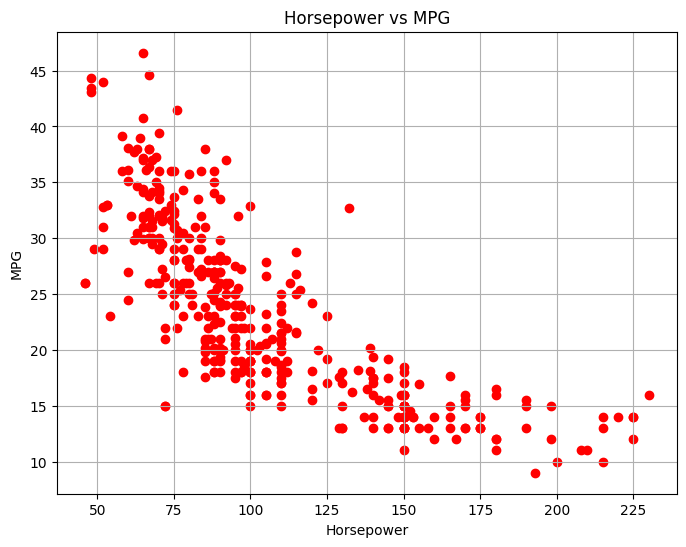

In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(X, y, color="red")

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs MPG")

plt.grid(True)

plt.show()

Step 6: Compute Correlation

In [22]:
correlation = df["horsepower"].corr(df["mpg"])

print("Correlation:", correlation)

Correlation: -0.7784267838977756


Step 7: Add Bias Term

In [23]:
X_bias = np.c_[np.ones(len(X)), X]

Step 8: Compute OLS Coefficients

In [24]:
theta = np.linalg.inv(X_bias.T.dot(X_bias)).dot(X_bias.T).dot(y)

intercept = theta[0]
slope = theta[1]

print("Intercept:", intercept)
print("Slope:", slope)

Intercept: 39.9358610211705
Slope: -0.15784473335365387


Step 9: Predict MPG

In [25]:
y_pred = X_bias.dot(theta)

Step 10: Calculate Residuals

In [26]:
residuals = y - y_pred

Step 11: Calculate SSE

In [27]:
SSE = np.sum((y - y_pred) ** 2)

print("SSE:", SSE)

SSE: 9385.915871932419


Step 12: Calculate MSE

In [28]:
MSE = np.mean((y - y_pred) ** 2)

print("MSE:", MSE)

MSE: 23.943662938603108


Step 13: Calculate R² Score

In [29]:
SST = np.sum((y - np.mean(y)) ** 2)

R2 = 1 - (SSE / SST)

print("R² Score:", R2)

R² Score: 0.6059482578894348


Step 14: Plot Regression Line

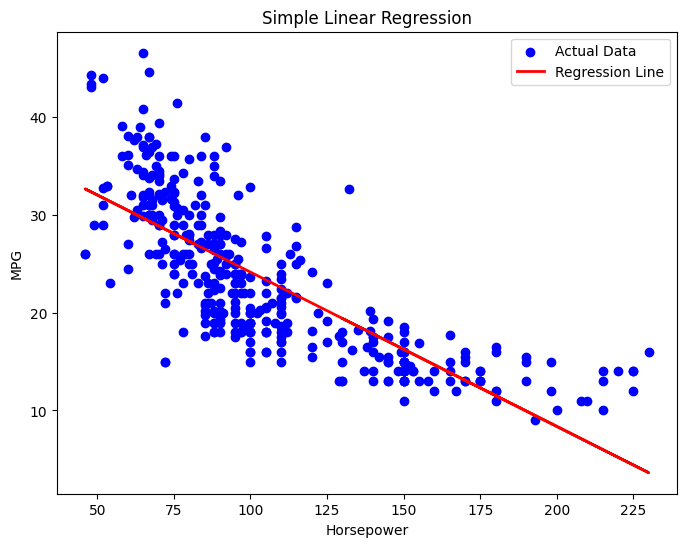

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(X, y, color="blue", label="Actual Data")

plt.plot(
    X,
    y_pred,
    color="red",
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Simple Linear Regression")

plt.legend()

plt.show()

Step 15: Plot Residual Graph — Regression Line

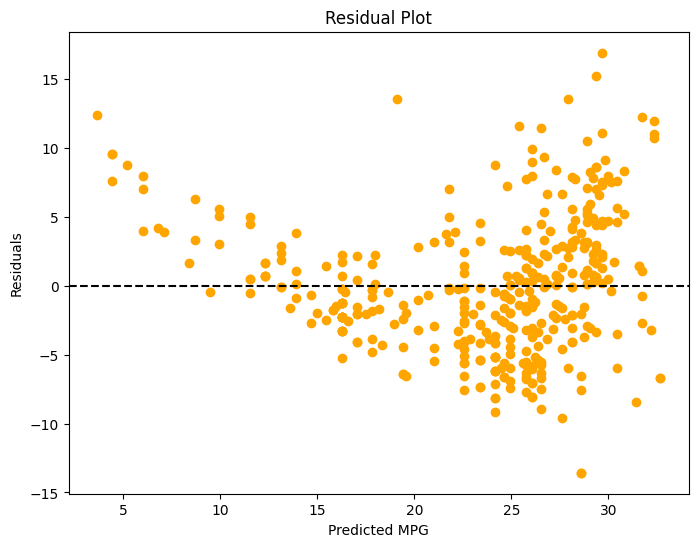

In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, color="orange")

plt.axhline(0, color="black", linestyle="--")

plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()